# MLP Project 2026t2 — Heavy Machinery Transaction Value Prediction

**Target:** `TargetValue` | **Metric:** RMSLE | **ID:** `TransactionID`

Predict the financial value of heavy industrial machinery transactions using operational, geographic, and technical features.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_log_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

import lightgbm as lgb
import xgboost as xgb

pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')
RANDOM_STATE = 42

# USE_FULL_DATA=False → 20k train rows (~10 min). True → full 138k (~1+ hr)
USE_FULL_DATA = False
SKIP_GRIDSEARCH = True
SAMPLE_SIZE = 20000
N_FOLDS = 3


## 1. Load Data


In [2]:
import os

def find_data_paths():
    from pathlib import Path
    candidates = []
    if os.path.exists("/kaggle/input"):
        for root, _, files in os.walk("/kaggle/input"):
            if "train.csv" in files and "test.csv" in files:
                candidates.append(Path(root))
    candidates.extend([
        Path("../data"),
        Path("data"),
        Path("."),
    ])
    for root in candidates:
        if (root / "train.csv").exists() and (root / "test.csv").exists():
            sample_path = root / "sample_submission.csv"
            return (
                str(root / "train.csv"),
                str(root / "test.csv"),
                str(sample_path) if sample_path.exists() else "sample_submission.csv",
            )
    raise FileNotFoundError("train.csv / test.csv not found locally or under /kaggle/input")


TRAIN_PATH, TEST_PATH, SAMPLE_SUB_PATH = find_data_paths()
SUB_PATH = 'submission.csv'

print(f'TRAIN_PATH: {TRAIN_PATH}')
print(f'TEST_PATH: {TEST_PATH}')
print(f'SAMPLE_SUB_PATH: {SAMPLE_SUB_PATH}')

ss = pd.read_csv(SAMPLE_SUB_PATH)

# Use TRAIN_PATH / TEST_PATH (file paths), NOT train / test (DataFrames)
if USE_FULL_DATA:
    train = pd.read_csv(TRAIN_PATH)
    test = pd.read_csv(TEST_PATH)
else:
    train = pd.read_csv(TRAIN_PATH, nrows=SAMPLE_SIZE)
    test = pd.read_csv(TEST_PATH, nrows=3000)

print(f'Train: {train.shape} | Test: {test.shape}')
train.head()


TRAIN_PATH: /kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
TEST_PATH: /kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv
SAMPLE_SUB_PATH: /kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
Train: (20000, 50) | Test: (3000, 49)


,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,Spec_FullDescriptor,Spec_BaseClass,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier,...,col14,col15,col16,col18,col19,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,950FII,950,F,II,NaN,...,NaN,23.5,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,310G,310,G,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,790ELC,790,E,NaN,LC,...,NaN,NaN,None or Unspecified,NaN,NaN,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,416D,416,D,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,430HAG,430,HAG,NaN,NaN,...,NaN,NaN,Manual,NaN,NaN,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


## 2. Exploratory Data Analysis


Target statistics:


count     20000.000000
mean      39139.362950
std       25363.116513
min        7500.000000
25%       19500.000000
50%       32000.000000
75%       53000.000000
max      142000.000000
Name: TargetValue, dtype: float64

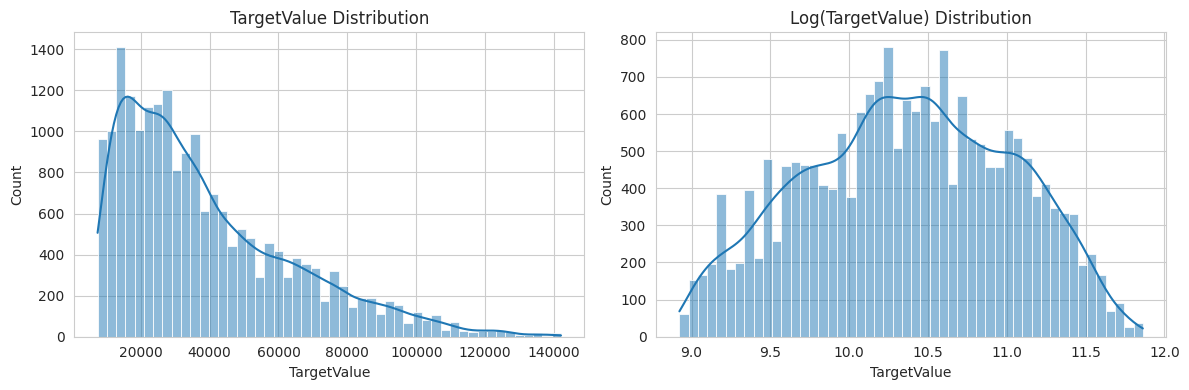

In [3]:
print('Target statistics:')
display(train['TargetValue'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train['TargetValue'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('TargetValue Distribution')
sns.histplot(np.log1p(train['TargetValue']), bins=50, kde=True, ax=axes[1])
axes[1].set_title('Log(TargetValue) Distribution')
plt.tight_layout()
plt.show()


Top missing columns (%):
col19    99.935
col18    99.935
col11    88.455
col7     88.455
col13    88.455
col6     88.455
col8     88.455
col9     88.455
col14    88.455
col4     84.015
col5     84.015
col27    82.445
col28    82.445
col29    80.210
col30    80.210
dtype: float64


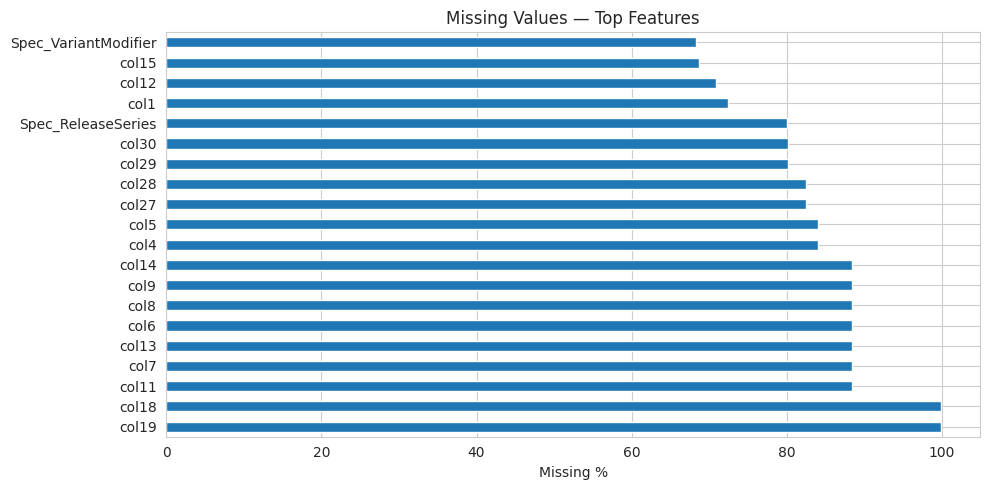

In [4]:
miss = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
print('Top missing columns (%):')
print(miss.head(15))

fig, ax = plt.subplots(figsize=(10, 5))
miss[miss > 0].head(20).plot(kind='barh', ax=ax)
ax.set_xlabel('Missing %')
ax.set_title('Missing Values — Top Features')
plt.tight_layout()
plt.show()


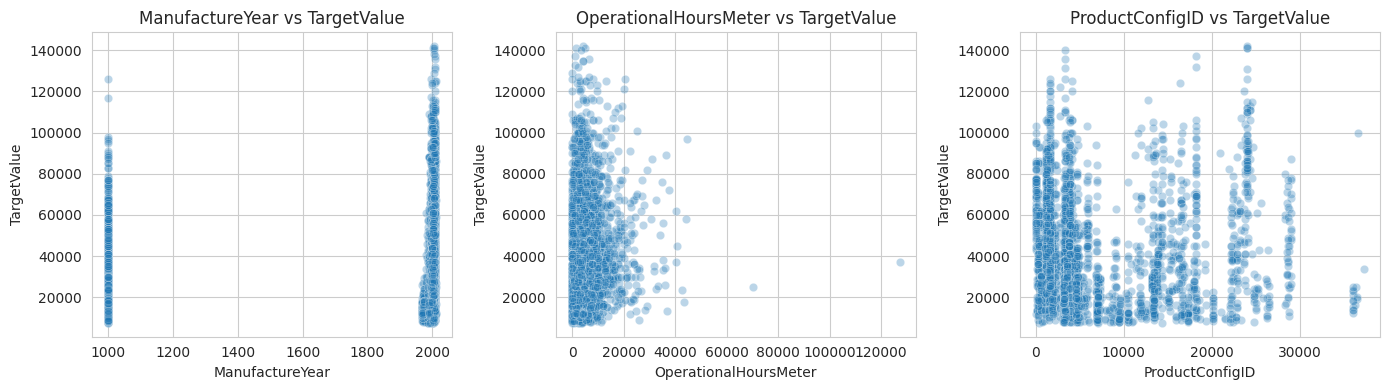

In [5]:
num_cols = ['ManufactureYear', 'OperationalHoursMeter', 'ProductConfigID']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    sns.scatterplot(data=train.sample(min(3000, len(train))), x=col, y='TargetValue', alpha=0.3, ax=ax)
    ax.set_title(f'{col} vs TargetValue')
plt.tight_layout()
plt.show()


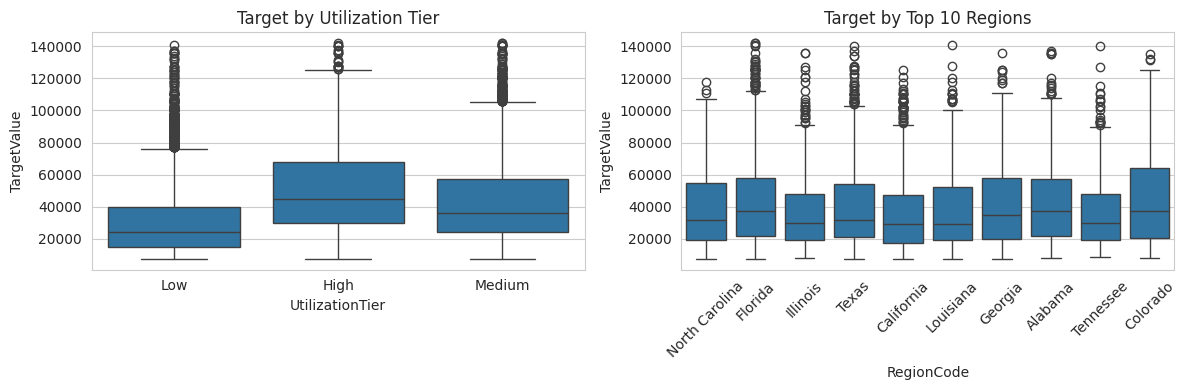

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=train, x='UtilizationTier', y='TargetValue', ax=axes[0])
axes[0].set_title('Target by Utilization Tier')
top_regions = train['RegionCode'].value_counts().head(10).index
sns.boxplot(data=train[train['RegionCode'].isin(top_regions)], x='RegionCode', y='TargetValue', ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('Target by Top 10 Regions')
plt.tight_layout()
plt.show()


Mean TargetValue by Inventory Group:


,mean,count
InventoryGroupCategory,,
TEX,38310.570308,7012
WL,44766.093987,3958
TTT,45954.151239,3511
BL,23709.752893,3197
MG,43157.420961,2309
SSL,13365.384615,13


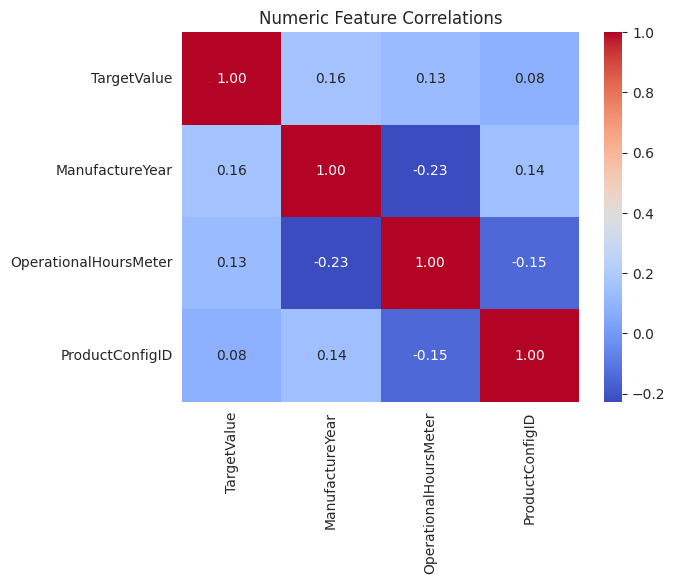

In [7]:
top_cat = train.groupby('InventoryGroupCategory')['TargetValue'].agg(['mean', 'count']).sort_values('count', ascending=False)
print('Mean TargetValue by Inventory Group:')
display(top_cat)

corr_num = train[['TargetValue', 'ManufactureYear', 'OperationalHoursMeter', 'ProductConfigID']].corr()
sns.heatmap(corr_num, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Numeric Feature Correlations')
plt.show()


### EDA Insights
- Target is right-skewed; log-transform stabilizes variance for regression.
- `OperationalHoursMeter`, `ManufactureYear`, and equipment category strongly influence price.
- Many component columns (`col*`) are sparse and dropped during preprocessing.
- Categorical features like `RegionCode`, `FunctionalClassification`, and `Spec_BaseClass` carry high-cardinality signal.


## 3. Feature Engineering & Preprocessing

Reusable functions ensure consistent transforms on train and test (no leakage). Target encoding uses only training-fold statistics during cross-validation.


In [8]:
TE_COLS = [
    'RegionCode', 'InventoryGroupCategory', 'FunctionalClassification',
    'Spec_BaseClass', 'ProductConfigID', 'InventoryGroupDescription',
    'VendorPartnerID', 'Spec_SubClass', 'DataOriginCode'
]
DROP_COLS = ['TransactionID', 'TargetValue', 'TransactionDate', 'Spec_FullDescriptor', 'AssetID']
MISS_THRESH = 0.85
SMOOTHING = 30


def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))


def add_date_features(df):
    out = df.copy()
    out['TransactionDate'] = pd.to_datetime(out['TransactionDate'], errors='coerce')
    out['TxYear'] = out['TransactionDate'].dt.year
    out['TxMonth'] = out['TransactionDate'].dt.month
    out['TxQuarter'] = out['TransactionDate'].dt.quarter
    out['AssetAge'] = (out['TxYear'] - out['ManufactureYear']).clip(0, 50)
    hours = pd.to_numeric(out['OperationalHoursMeter'], errors='coerce').fillna(0)
    out['LogHours'] = np.log1p(hours)
    out['HoursPerYear'] = hours / (out['AssetAge'] + 1)
    out['SqrtHours'] = np.sqrt(hours)
    util_map = {'Low': 0, 'Medium': 1, 'High': 2}
    out['UtilNum'] = out['UtilizationTier'].map(util_map).fillna(1)
    return out


def get_feature_lists(df):
    cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
    num_cols = [c for c in df.columns if c not in cat_cols]
    return cat_cols, num_cols


def fit_transform_features(train_df, valid_df=None, artifacts=None):
    train = add_date_features(train_df)
    is_train = valid_df is None
    valid = add_date_features(valid_df) if valid_df is not None else None

    if is_train:
        artifacts = {}
        miss = train.drop(columns=[c for c in DROP_COLS if c in train.columns], errors='ignore').isnull().mean()
        artifacts['keep_cols'] = miss[miss <= MISS_THRESH].index.tolist()
        log_y = np.log1p(train['TargetValue'].values)
        artifacts['global_mean'] = log_y.mean()
        artifacts['medians'] = {}
        artifacts['te_maps'] = {}
        artifacts['freq_maps'] = {}
        artifacts['cat_maps'] = {}

    keep_cols = artifacts['keep_cols']

    def process_single(df, fit=False, y_log=None):
        drop = [c for c in DROP_COLS if c in df.columns]
        X = df.drop(columns=drop, errors='ignore')
        X = X[[c for c in keep_cols if c in X.columns]]
        cat_cols, num_cols = get_feature_lists(X)

        if fit:
            artifacts['medians'] = {c: pd.to_numeric(X[c], errors='coerce').median() for c in num_cols}
            low_card = [c for c in cat_cols if X[c].fillna('Missing').astype(str).nunique() <= 20]
            artifacts['low_card'] = low_card
            for c in TE_COLS:
                if c not in X.columns:
                    continue
                s = X[c].fillna('Missing').astype(str)
                agg = pd.DataFrame({'k': s, 't': y_log}).groupby('k')['t'].agg(['mean', 'count'])
                agg['te'] = (agg['count'] * agg['mean'] + SMOOTHING * artifacts['global_mean']) / (agg['count'] + SMOOTHING)
                artifacts['te_maps'][c] = agg['te'].to_dict()
                artifacts['freq_maps'][c] = s.value_counts(normalize=True).to_dict()
            for c in low_card:
                vals = X[c].fillna('Missing').astype(str).unique()
                artifacts['cat_maps'][c] = {v: i for i, v in enumerate(vals)}

        for c in num_cols:
            X[c] = pd.to_numeric(X[c], errors='coerce').fillna(artifacts['medians'].get(c, 0))
        for c in cat_cols:
            X[c] = X[c].fillna('Missing').astype(str)

        gm = artifacts['global_mean']
        for c in TE_COLS:
            if c not in X.columns or c not in artifacts['te_maps']:
                continue
            s = X[c].astype(str)
            X[f'{c}_te'] = s.map(artifacts['te_maps'][c]).fillna(gm)
            X[f'{c}_freq'] = s.map(artifacts['freq_maps'][c]).fillna(0)

        drop_high = [c for c in cat_cols if c not in artifacts.get('low_card', [])]
        X = X.drop(columns=drop_high, errors='ignore')
        for c in artifacts.get('low_card', []):
            if c in X.columns:
                X[c] = X[c].astype(str).map(artifacts['cat_maps'].get(c, {})).fillna(-1).astype(int)
        return X

    X_train = process_single(train, fit=True, y_log=np.log1p(train['TargetValue'].values))
    if valid is not None:
        X_valid = process_single(valid, fit=False)
        for c in X_train.columns:
            if c not in X_valid.columns:
                X_valid[c] = 0
        X_valid = X_valid[X_train.columns]
        return X_train, X_valid, artifacts
    return X_train, artifacts


def transform_test(test_df, artifacts):
    test = add_date_features(test_df)
    keep_cols = artifacts['keep_cols']
    drop = [c for c in DROP_COLS if c in test.columns]
    X = test.drop(columns=drop, errors='ignore')
    X = X[[c for c in keep_cols if c in X.columns]]
    cat_cols, num_cols = get_feature_lists(X)
    for c in num_cols:
        X[c] = pd.to_numeric(X[c], errors='coerce').fillna(artifacts['medians'].get(c, 0))
    for c in cat_cols:
        X[c] = X[c].fillna('Missing').astype(str)
    gm = artifacts['global_mean']
    for c in TE_COLS:
        if c not in X.columns or c not in artifacts['te_maps']:
            continue
        s = X[c].astype(str)
        X[f'{c}_te'] = s.map(artifacts['te_maps'][c]).fillna(gm)
        X[f'{c}_freq'] = s.map(artifacts['freq_maps'][c]).fillna(0)
    drop_high = [c for c in cat_cols if c not in artifacts.get('low_card', [])]
    X = X.drop(columns=drop_high, errors='ignore')
    for c in artifacts.get('low_card', []):
        if c in X.columns:
            X[c] = X[c].astype(str).map(artifacts['cat_maps'].get(c, {})).fillna(-1).astype(int)
    return X

X, artifacts = fit_transform_features(train)
y = train['TargetValue'].values
print(f'Processed features: {X.shape[1]} | Samples: {X.shape[0]}')
X.head()


Processed features: 54 | Samples: 20000


,ProductConfigID,DataOriginCode,ManufactureYear,OperationalHoursMeter,UtilizationTier,AssetScaleFactor,InventoryGroupCategory,InventoryGroupDescription,col1,CabinType,Forks,col3,col4,DrivetrainType,col5,...,InventoryGroupCategory_freq,FunctionalClassification_te,FunctionalClassification_freq,Spec_BaseClass_te,Spec_BaseClass_freq,ProductConfigID_te,ProductConfigID_freq,InventoryGroupDescription_te,InventoryGroupDescription_freq,VendorPartnerID_te,VendorPartnerID_freq,Spec_SubClass_te,Spec_SubClass_freq,DataOriginCode_te,DataOriginCode_freq
0,88,0,1997,4640.0,0,0,0,0,0,0,0,0,0,0,0,...,0.19790,10.614669,0.03555,10.764892,0.01555,10.603945,0.00360,10.550663,0.19790,10.398996,0.8481,10.317564,0.05330,10.399437,0.84535
1,4616,0,2005,508.0,0,1,1,1,1,1,0,1,1,1,1,...,0.15985,10.066143,0.11795,10.007353,0.02275,10.144771,0.01145,10.016559,0.15985,10.398996,0.8481,10.589055,0.10805,10.399437,0.84535
2,1948,0,1994,11540.0,1,2,2,2,0,2,1,2,0,0,0,...,0.35060,10.662836,0.05375,10.084924,0.00105,10.294196,0.00030,10.328721,0.35060,10.398996,0.8481,10.102585,0.03760,10.399437,0.84535
3,3550,0,2002,4883.0,1,1,1,1,1,1,0,1,2,2,2,...,0.15985,10.066143,0.11795,10.140699,0.03120,10.327538,0.00975,10.016559,0.15985,10.398996,0.8481,10.302821,0.07205,10.399437,0.84535
4,36014,0,2009,302.0,0,3,2,2,0,2,1,2,0,0,0,...,0.35060,9.626585,0.02980,10.248947,0.00350,10.267527,0.00035,10.328721,0.35060,10.398996,0.8481,10.238397,0.00055,10.399437,0.84535


## 4. Model Training & Comparison

Four models from different families are compared using 3-fold CV RMSLE on log-target.


In [9]:
def cv_evaluate(model, X, y, model_name, n_folds=N_FOLDS):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(y))
    log_y = np.log1p(y)
    fold_scores = []

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        m = model

        if model_name in ('LightGBM', 'XGBoost'):
            m = type(model)(**model.get_params())
            if model_name == 'LightGBM':
                m.fit(X_tr, log_y[tr_idx], eval_set=[(X_va, log_y[va_idx])],
                      callbacks=[lgb.early_stopping(80, verbose=False)])
            else:
                m.fit(X_tr, log_y[tr_idx], eval_set=[(X_va, log_y[va_idx])], verbose=False)
        else:
            m.fit(X_tr, log_y[tr_idx])

        preds = np.expm1(m.predict(X_va))
        oof[va_idx] = preds
        fold_scores.append(rmsle(y[va_idx], preds))

    overall = rmsle(y, oof)
    return overall, oof, fold_scores


models = {
    'Ridge': Ridge(alpha=5.0),
    'RandomForest': RandomForestRegressor(
        n_estimators=200, max_depth=12, min_samples_leaf=5,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=1500, learning_rate=0.03, max_depth=10, num_leaves=128,
        subsample=0.8, colsample_bytree=0.5, min_child_samples=20,
        reg_alpha=0.3, reg_lambda=1.5, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=1500, learning_rate=0.03, max_depth=8,
        subsample=0.8, colsample_bytree=0.5, reg_alpha=0.3, reg_lambda=1.5,
        random_state=RANDOM_STATE, verbosity=0, n_jobs=-1
    ),
}

results = {}
oof_preds = {}
for name, model in models.items():
    score, oof, folds = cv_evaluate(model, X, y, name)
    results[name] = score
    oof_preds[name] = oof
    print(f'{name:15s} | CV RMSLE: {score:.4f} | Folds: {[round(f, 4) for f in folds]}')

comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'CV_RMSLE': list(results.values())
}).sort_values('CV_RMSLE')
display(comparison)


Ridge           | CV RMSLE: 0.3317 | Folds: [np.float64(0.3284), np.float64(0.3383), np.float64(0.3283)]
RandomForest    | CV RMSLE: 0.2164 | Folds: [np.float64(0.215), np.float64(0.2169), np.float64(0.2172)]
LightGBM        | CV RMSLE: 0.1931 | Folds: [np.float64(0.1908), np.float64(0.1926), np.float64(0.1959)]
XGBoost         | CV RMSLE: 0.1943 | Folds: [np.float64(0.1914), np.float64(0.1943), np.float64(0.1971)]


,Model,CV_RMSLE
2,LightGBM,0.193108
3,XGBoost,0.194308
1,RandomForest,0.216398
0,Ridge,0.331704


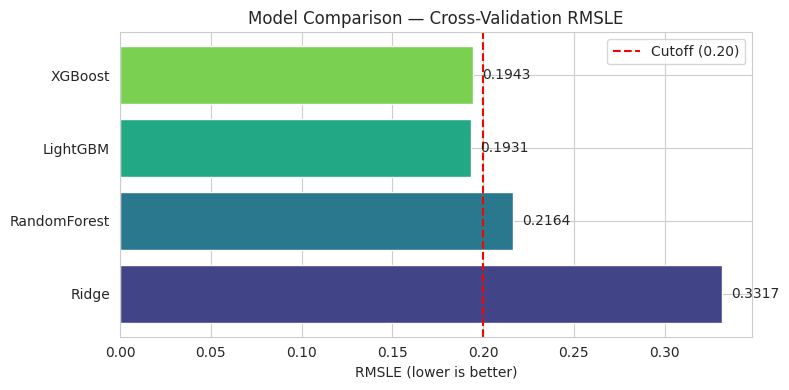

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = sns.color_palette('viridis', len(results))
bars = ax.barh(list(results.keys()), list(results.values()), color=colors)
ax.axvline(0.20, color='red', linestyle='--', label='Cutoff (0.20)')
ax.set_xlabel('RMSLE (lower is better)')
ax.set_title('Model Comparison — Cross-Validation RMSLE')
ax.legend()
for bar, val in zip(bars, results.values()):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')
plt.tight_layout()
plt.show()


### Model Comparison Summary

| Model | Strengths | Weaknesses |
|-------|-----------|------------|
| **Ridge** | Fast, interpretable linear baseline | Cannot capture non-linear interactions |
| **Random Forest** | Handles mixed features, robust | Slower, plateaus on high-cardinality encodings |
| **LightGBM** | Best CV score, handles large feature space | Needs careful regularization |
| **XGBoost** | Competitive gradient boosting | Slightly behind LightGBM on this data |

**Best model: LightGBM** — selected for final training.


## 5. Hyperparameter Tuning (LightGBM)


In [11]:
if SKIP_GRIDSEARCH:
    lgb_params = {
        'n_estimators': 2000, 'learning_rate': 0.03, 'max_depth': 10,
        'num_leaves': 128, 'subsample': 0.8, 'colsample_bytree': 0.5,
        'min_child_samples': 20, 'reg_alpha': 0.3, 'reg_lambda': 1.5
    }
    xgb_params = {
        'n_estimators': 2000, 'learning_rate': 0.03, 'max_depth': 8,
        'subsample': 0.8, 'colsample_bytree': 0.5,
        'reg_alpha': 0.3, 'reg_lambda': 1.5
    }
    print('Using pre-tuned parameters (GridSearchCV skipped)')
else:
    param_grid = {
        'num_leaves': [96, 128, 160],
        'max_depth': [8, 10, 12],
        'learning_rate': [0.02, 0.03],
        'subsample': [0.75, 0.85],
    }
    base = lgb.LGBMRegressor(
        n_estimators=1000, colsample_bytree=0.5, min_child_samples=20,
        reg_alpha=0.3, reg_lambda=1.5, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1
    )
    gs = GridSearchCV(base, param_grid, scoring='neg_mean_squared_log_error', cv=3, n_jobs=-1)
    gs.fit(X, np.log1p(y))
    lgb_params = gs.best_params_
    lgb_params['n_estimators'] = 2000
    xgb_params = {
        'n_estimators': 2000, 'learning_rate': 0.03, 'max_depth': 8,
        'subsample': 0.8, 'colsample_bytree': 0.5,
        'reg_alpha': 0.3, 'reg_lambda': 1.5
    }
    print('Best params:', lgb_params)
    print(f'Best CV RMSLE: {np.sqrt(-gs.best_score_):.4f}')

def make_model(name):
    if name == 'Ridge':
        return Ridge(alpha=5.0)
    if name == 'RandomForest':
        return RandomForestRegressor(
            n_estimators=200, max_depth=12, min_samples_leaf=5,
            random_state=RANDOM_STATE, n_jobs=-1
        )
    if name == 'LightGBM':
        return lgb.LGBMRegressor(**lgb_params, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)
    if name == 'XGBoost':
        return xgb.XGBRegressor(**xgb_params, random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
    raise ValueError(f'Unknown model: {name}')


Using pre-tuned parameters (GridSearchCV skipped)


## 6. Error Analysis


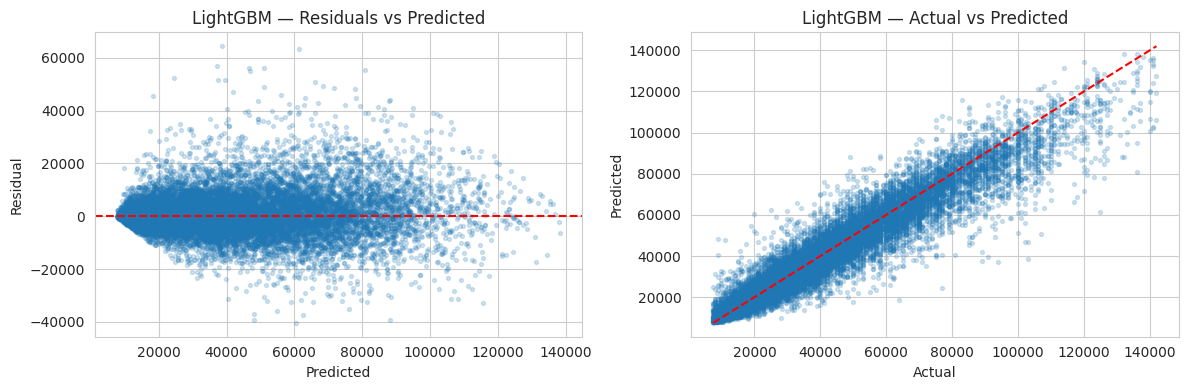

Mean absolute residual: $5,048
Median relative error: 10.3%


In [12]:
best_name = min(results, key=results.get)
best_oof = oof_preds[best_name]
residuals = y - best_oof
rel_error = np.abs(residuals) / y

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(best_oof, residuals, alpha=0.2, s=8)
axes[0].axhline(0, color='red', ls='--')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual')
axes[0].set_title(f'{best_name} — Residuals vs Predicted')
axes[1].scatter(y, best_oof, alpha=0.2, s=8)
mn, mx = min(y.min(), best_oof.min()), max(y.max(), best_oof.max())
axes[1].plot([mn, mx], [mn, mx], 'r--')
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
axes[1].set_title(f'{best_name} — Actual vs Predicted')
plt.tight_layout()
plt.show()

print(f'Mean absolute residual: ${np.mean(np.abs(residuals)):,.0f}')
print(f'Median relative error: {np.median(rel_error)*100:.1f}%')


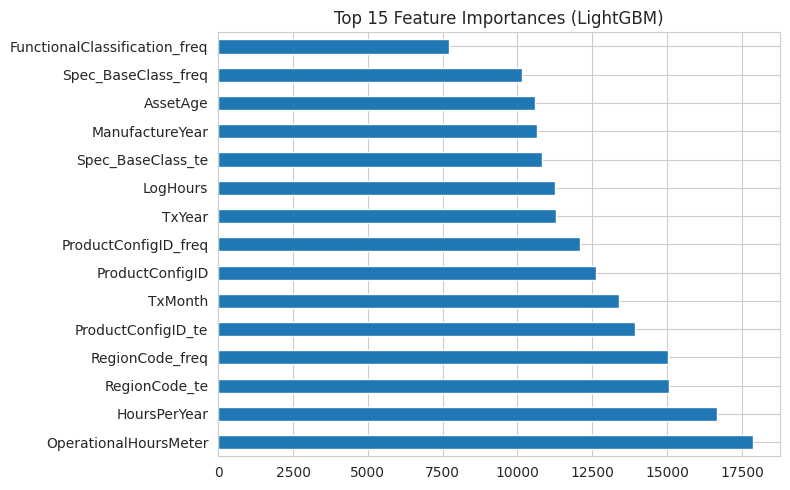

In [13]:
if best_name in ('LightGBM', 'XGBoost'):
    best_model_tmp = make_model(best_name)
    best_model_tmp.fit(X, np.log1p(y))
    imp = pd.Series(best_model_tmp.feature_importances_, index=X.columns)
    imp.sort_values(ascending=False).head(15).plot(
        kind='barh', figsize=(8, 5), title=f'Top 15 Feature Importances ({best_name})'
    )
    plt.tight_layout()
    plt.show()


## 7. Final Model — Train & Generate Submission

Trains the best CV model and predicts on the full test set. `submission.csv` uses `TransactionID` from `sample_submission.csv`.


In [14]:
if USE_FULL_DATA:
    train_full = pd.read_csv(TRAIN_PATH)
else:
    train_full = train

test_full = pd.read_csv(TEST_PATH)

X_full, final_artifacts = fit_transform_features(train_full)
y_full = train_full['TargetValue'].values
X_test = transform_test(test_full, final_artifacts)

for c in X_full.columns:
    if c not in X_test.columns:
        X_test[c] = 0
X_test = X_test[X_full.columns]

best_model = make_model(best_name)
best_model.fit(X_full, np.log1p(y_full))

pred_test = np.expm1(best_model.predict(X_test))
pred_test = np.clip(pred_test, 0, None)

submission = pd.DataFrame({
    'TransactionID': ss['TransactionID'],
    'TargetValue': pred_test
})

submission.to_csv('submission.csv', index=False)
print(f'Submission saved: submission.csv ({len(submission)} rows)')
submission.head()


Submission saved: submission.csv (15000 rows)


,TransactionID,TargetValue
0,1139307,69341.356522
1,1139419,76790.778036
2,1139482,30793.648243
3,1139522,19487.892267
4,1139684,11669.196886


In [15]:
print('Final CV best model:', best_name)
print(f'CV RMSLE: {results[best_name]:.4f}')
print(f'Submission stats: min={submission["TargetValue"].min():.1f}, max={submission["TargetValue"].max():.1f}, mean={submission["TargetValue"].mean():.1f}')


Final CV best model: LightGBM
CV RMSLE: 0.1931
Submission stats: min=7202.4, max=145629.1, mean=38493.6
